In [220]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [221]:
data_file = pd.read_csv('glass.txt', delimiter=r'\s+')
data = data_file[['RI', 'Al']]

x_data = data['RI'].values
y_data = data['Al'].values

In [222]:
class UniformKDE:
    def __init__(self, bandwidth=1.0):
        """Initialize the KDE model with the given bandwidth."""
        self.bandwidth = bandwidth
        self.data = None
        self.y_data = None

    def fit(self, x_data, y_data):
        """Fit the KDE model with the given x and y data."""
        self.data = x_data
        self.y_data = y_data

    def __uniform_kernel(self, x):
        """Uniform kernel function."""
        return np.where(np.abs(x) <= 0.5, 1, 0)

    def kernel(self, x, xi):
        """Applies the uniform kernel to the data."""
        return self.__uniform_kernel((x - xi) / self.bandwidth)
    

    def predict(self, x):
        """Evaluate the Nadaraya-Watson estimator at points x."""
        func_val = []
        for point in x:
            weights = self.kernel(point, self.data)
            numerator = np.sum(weights * self.y_data)
            denominator = np.sum(weights)
            
            if denominator > 0:
                func_val.append(numerator / denominator)
            else:
                func_val.append(0)  # Handle division by zero case
        return np.array(func_val)

In [223]:
def calculate_risk(kde, x_data, y_true):
    """Calculate the mean squared error (MSE) as risk."""
    y_pred = kde.predict(x_data)
    mse = np.mean((y_true - y_pred) ** 2)
    return mse

In [224]:
def risk_val(func):
    bandwidths = np.linspace(0, 10, 50)

    # Store risks for each bandwidth
    risks = []

    # Loop over bandwidths to compute risk
    for bandwidth in bandwidths:
        # Create an instance of the UniformKDE class
        kde = func(bandwidth=bandwidth)

        # Fit the model with the data
        kde.fit(x_data, y_data)

        # Calculate risk (mean squared error)
        risk = calculate_risk(kde, x_data, y_data)
        risks.append(risk)
        
    return bandwidths, risks, bandwidths[np.argmin(risks)]


In [225]:
bandwidths_Ukde, risks_Ukde, best_bandwidth_Ukde = risk_val(UniformKDE)

/tmp/ipykernel_710979/2374187113.py:19: RuntimeWarning: divide by zero encountered in divide
  return self.__uniform_kernel((x - xi) / self.bandwidth)
/tmp/ipykernel_710979/2374187113.py:19: RuntimeWarning: invalid value encountered in divide
  return self.__uniform_kernel((x - xi) / self.bandwidth)


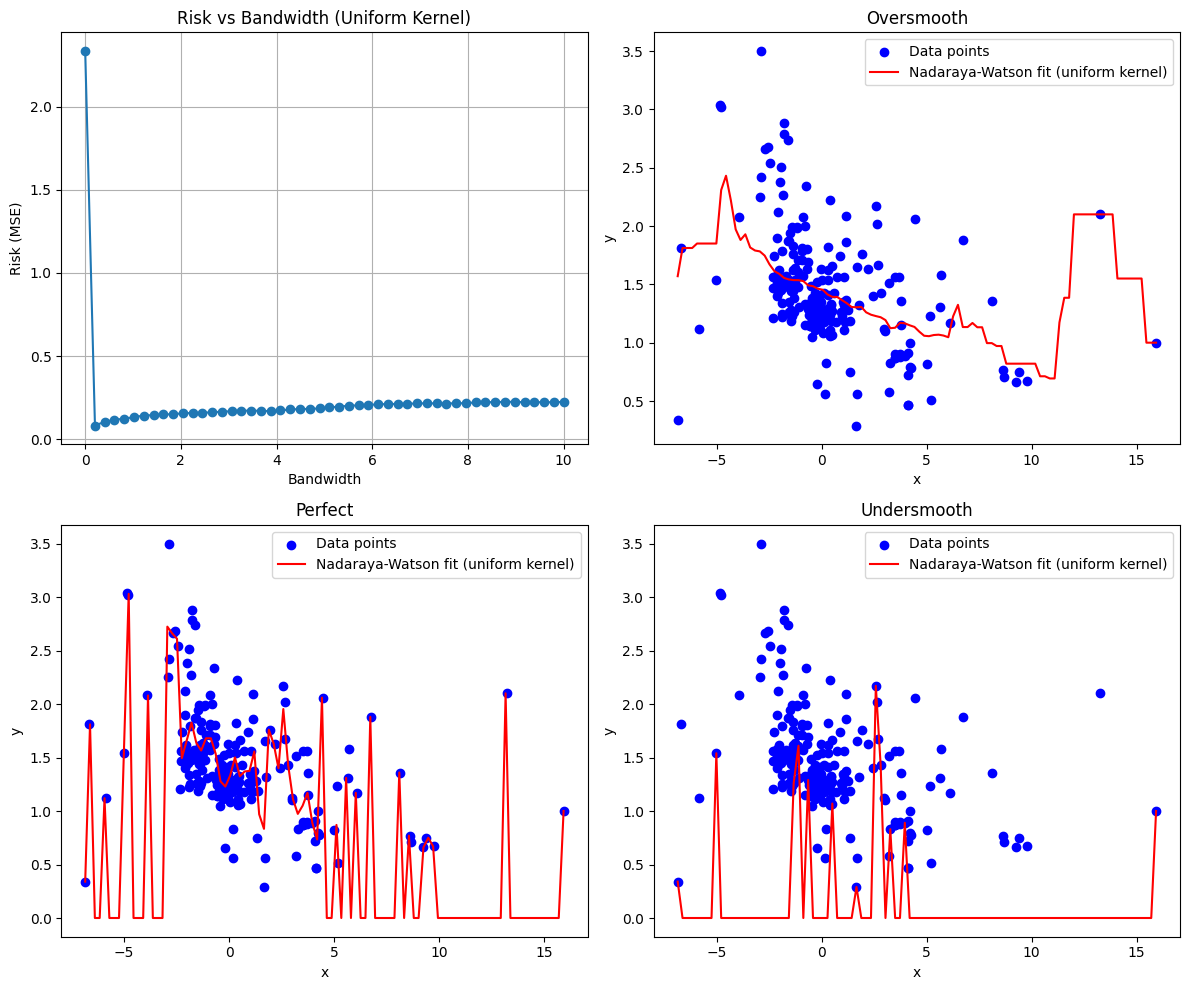

In [226]:
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

# Plot risk vs bandwidth
axs[0, 0].plot(bandwidths_Ukde, risks_Ukde, marker='o')
axs[0, 0].set_title('Risk vs Bandwidth (Uniform Kernel)')
axs[0, 0].set_xlabel('Bandwidth')
axs[0, 0].set_ylabel('Risk (MSE)')
axs[0, 0].grid(True)

# Oversmooth
kde = UniformKDE(bandwidth=best_bandwidth_Ukde * 20)
kde.fit(x_data, y_data)
x_fit = np.linspace(min(x_data), max(x_data), 100)
y_fit = kde.predict(x_fit)
axs[0, 1].scatter(x_data, y_data, color='blue', label='Data points')
axs[0, 1].plot(x_fit, y_fit, color='red', label='Nadaraya-Watson fit (uniform kernel)')
axs[0, 1].set_title('Oversmooth')
axs[0, 1].set_xlabel('x')
axs[0, 1].set_ylabel('y')
axs[0, 1].legend()

# perfect
kde = UniformKDE(bandwidth=best_bandwidth_Ukde)
kde.fit(x_data, y_data)
y_fit = kde.predict(x_fit)
axs[1, 0].scatter(x_data, y_data, color='blue', label='Data points')
axs[1, 0].plot(x_fit, y_fit, color='red', label='Nadaraya-Watson fit (uniform kernel)')
axs[1, 0].set_title('Perfect')
axs[1, 0].set_xlabel('x')
axs[1, 0].set_ylabel('y')
axs[1, 0].legend()

# undersmooth
kde = UniformKDE(bandwidth=best_bandwidth_Ukde / 20)
kde.fit(x_data, y_data)
y_fit = kde.predict(x_fit)
axs[1, 1].scatter(x_data, y_data, color='blue', label='Data points')
axs[1, 1].plot(x_fit, y_fit, color='red', label='Nadaraya-Watson fit (uniform kernel)')
axs[1, 1].set_title('Undersmooth')
axs[1, 1].set_xlabel('x')
axs[1, 1].set_ylabel('y')
axs[1, 1].legend()


plt.tight_layout()
plt.show()

In [227]:
print(f"bandwidth corresponding to minimum estimated risk is {best_bandwidth}")

bandwidth corresponding to minimum estimated risk is 0.20408163265306123


In [228]:
class EpanechnikovKDE:
    def __init__(self, bandwidth=1.0):
        """Initialize the KDE model with the given bandwidth."""
        self.bandwidth = bandwidth
        self.data = None
        self.y_data = None

    def fit(self, x_data, y_data):
        """Fit the KDE model with the given x and y data."""
        self.data = x_data
        self.y_data = y_data

    def __epanechnikov(self, x):
        # mod_x_squared=np.sum(x**2, axis=-1)
        return np.maximum(0, 0.75*(1-x**2))

    def epanechnikov_kernel(self, x, xi):
        """Epanechnikov kernel function."""
        
        return self.__epanechnikov((x-xi)/self.bandwidth)
        
    

    def predict(self, x):
        """Evaluate the Nadaraya-Watson estimator at points x."""
        func_val = []
        for point in x:
            weights = self.epanechnikov_kernel(point, self.data)
            numerator = np.sum(weights * self.y_data)
            denominator = np.sum(weights)
            
            if denominator > 0:
                func_val.append(numerator / denominator)
            else:
                func_val.append(0)  # Handle division by zero case
        return np.array(func_val)

In [229]:
bandwidths_Ekde, risks_Ekde, best_bandwidth_Ekde = risk_val(EpanechnikovKDE)

/tmp/ipykernel_710979/1220801899.py:20: RuntimeWarning: divide by zero encountered in divide
  return self.__epanechnikov((x-xi)/self.bandwidth)
/tmp/ipykernel_710979/1220801899.py:20: RuntimeWarning: invalid value encountered in divide
  return self.__epanechnikov((x-xi)/self.bandwidth)


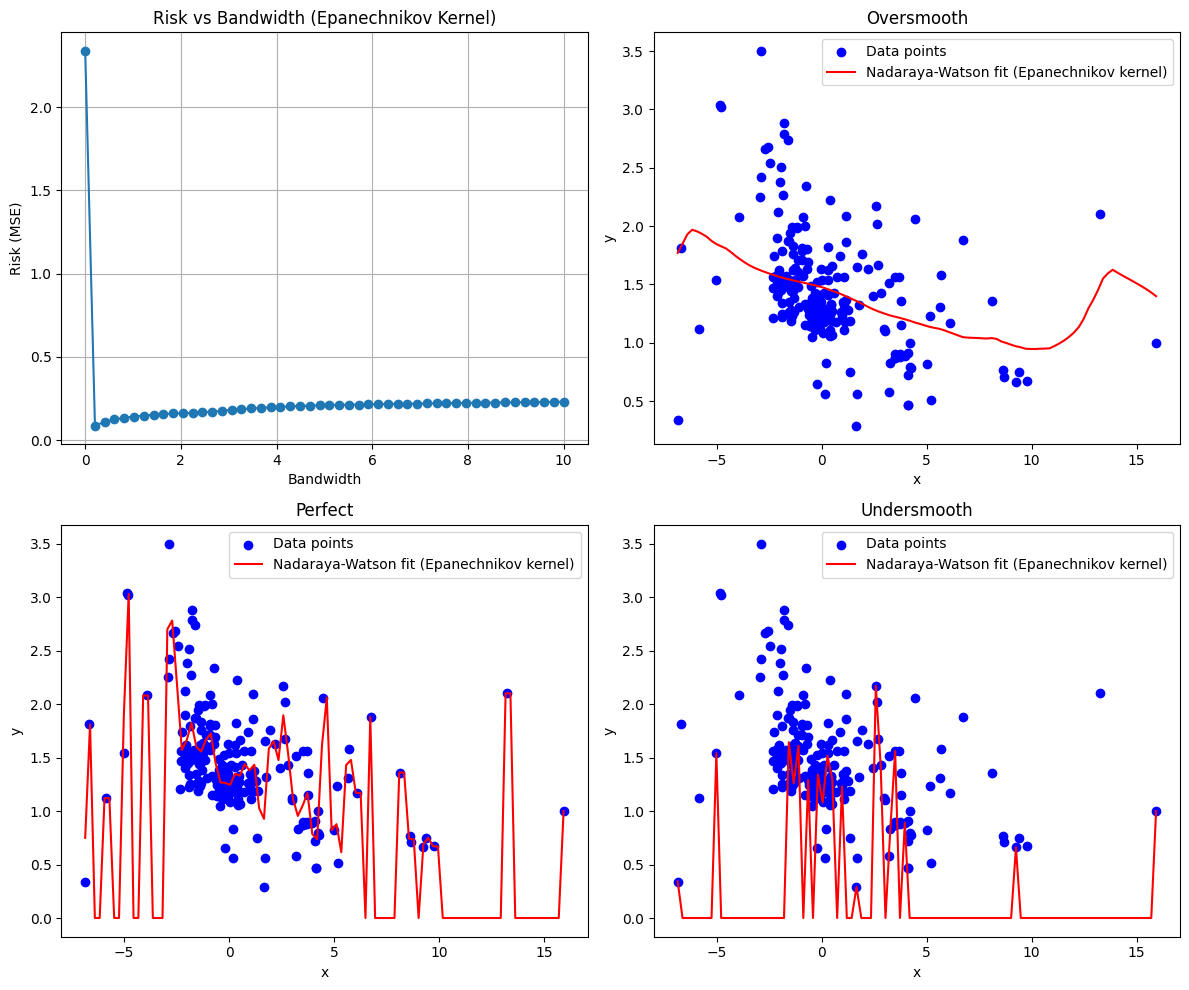

In [230]:
# Create subplots
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

# Plot risk vs bandwidth
axs[0, 0].plot(bandwidths_Ekde, risks_Ekde, marker='o')
axs[0, 0].set_title('Risk vs Bandwidth (Epanechnikov Kernel)')
axs[0, 0].set_xlabel('Bandwidth')
axs[0, 0].set_ylabel('Risk (MSE)')
axs[0, 0].grid(True)

# Oversmooth
kde = EpanechnikovKDE(bandwidth=best_bandwidth_Ekde * 20)
kde.fit(x_data, y_data)
x_fit = np.linspace(min(x_data), max(x_data), 100)
y_fit = kde.predict(x_fit)
axs[0, 1].scatter(x_data, y_data, color='blue', label='Data points')
axs[0, 1].plot(x_fit, y_fit, color='red', label='Nadaraya-Watson fit (Epanechnikov kernel)')
axs[0, 1].set_title('Oversmooth')
axs[0, 1].set_xlabel('x')
axs[0, 1].set_ylabel('y')
axs[0, 1].legend()

# perfect
kde = EpanechnikovKDE(bandwidth=best_bandwidth_Ekde)
kde.fit(x_data, y_data)
y_fit = kde.predict(x_fit)
axs[1, 0].scatter(x_data, y_data, color='blue', label='Data points')
axs[1, 0].plot(x_fit, y_fit, color='red', label='Nadaraya-Watson fit (Epanechnikov kernel)')
axs[1, 0].set_title('Perfect')
axs[1, 0].set_xlabel('x')
axs[1, 0].set_ylabel('y')
axs[1, 0].legend()

# undersmooth
kde = EpanechnikovKDE(bandwidth=best_bandwidth_Ekde / 20)
kde.fit(x_data, y_data)
y_fit = kde.predict(x_fit)
axs[1, 1].scatter(x_data, y_data, color='blue', label='Data points')
axs[1, 1].plot(x_fit, y_fit, color='red', label='Nadaraya-Watson fit (Epanechnikov kernel)')
axs[1, 1].set_title('Undersmooth')
axs[1, 1].set_xlabel('x')
axs[1, 1].set_ylabel('y')
axs[1, 1].legend()

plt.tight_layout()
plt.show()

In [231]:
# plt.savefig("epanechnikov_kernel_regression.png")

In [232]:
print(f"bandwidth corresponding to minimum estimated risk is {best_bandwidth}")

bandwidth corresponding to minimum estimated risk is 0.20408163265306123


1. Can you empirically corroborate above statement using plots ? Are all kernel functions similarly dependent on choice of optimal bandwidth ?



Comparing plots of each function

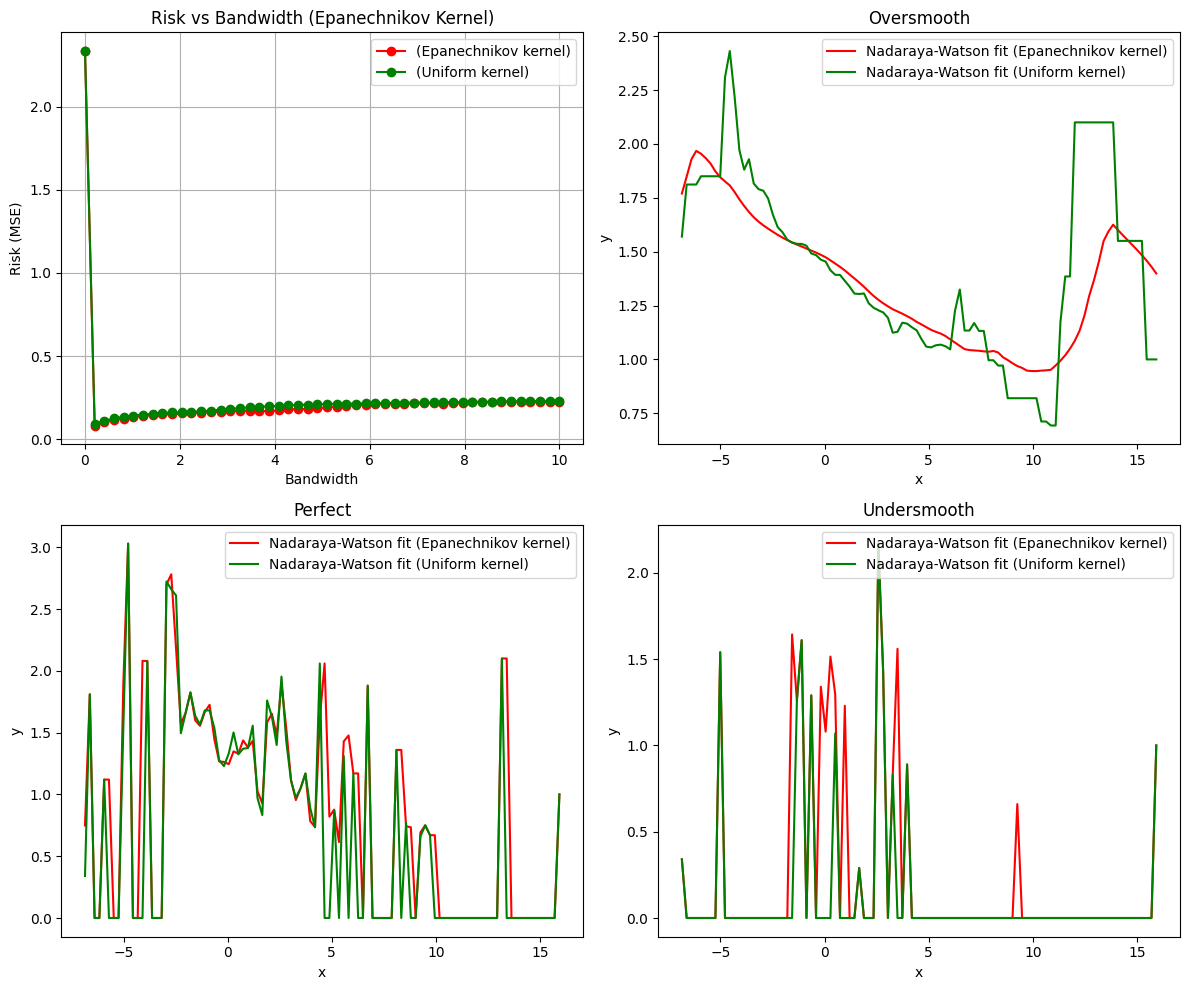

In [233]:
# Create subplots
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

# Plot risk vs bandwidth
axs[0, 0].plot(bandwidths_Ukde, risks_Ukde, color='red', marker='o', label='(Epanechnikov kernel)')
axs[0, 0].plot(bandwidths_Ekde, risks_Ekde, color='green', marker='o', label='(Uniform kernel)')
axs[0, 0].set_title('Risk vs Bandwidth (Epanechnikov Kernel)')
axs[0, 0].set_xlabel('Bandwidth')
axs[0, 0].set_ylabel('Risk (MSE)')
axs[0, 0].grid(True)
axs[0, 0].legend()

# Oversmooth
Ekde = EpanechnikovKDE(bandwidth=best_bandwidth_Ekde * 20)
Ekde.fit(x_data, y_data)
x_fitE = np.linspace(min(x_data), max(x_data), 100)
y_fitE = Ekde.predict(x_fit)

Ukde = UniformKDE(bandwidth=best_bandwidth_Ukde * 20)
Ukde.fit(x_data, y_data)
x_fitU = np.linspace(min(x_data), max(x_data), 100)
y_fitU = Ukde.predict(x_fit)

# axs[0, 1].scatter(x_data, y_data, color='blue', label='Data points')
axs[0, 1].plot(x_fitE, y_fitE, color='red', label='Nadaraya-Watson fit (Epanechnikov kernel)')
axs[0, 1].plot(x_fitU, y_fitU, color='green', label='Nadaraya-Watson fit (Uniform kernel)')
axs[0, 1].set_title('Oversmooth')
axs[0, 1].set_xlabel('x')
axs[0, 1].set_ylabel('y')
axs[0, 1].legend()

# perfect
Ekde = EpanechnikovKDE(bandwidth=best_bandwidth_Ekde )
Ekde.fit(x_data, y_data)
x_fitE = np.linspace(min(x_data), max(x_data), 100)
y_fitE = Ekde.predict(x_fit)

Ukde = UniformKDE(bandwidth=best_bandwidth_Ukde)
Ukde.fit(x_data, y_data)
x_fitU = np.linspace(min(x_data), max(x_data), 100)
y_fitU = Ukde.predict(x_fit)

# axs[1, 0].scatter(x_data, y_data, color='blue', label='Data points')
axs[1, 0].plot(x_fitE, y_fitE, color='red', label='Nadaraya-Watson fit (Epanechnikov kernel)')
axs[1, 0].plot(x_fitU, y_fitU, color='green', label='Nadaraya-Watson fit (Uniform kernel)')
axs[1, 0].set_title('Perfect')
axs[1, 0].set_xlabel('x')
axs[1, 0].set_ylabel('y')
axs[1, 0].legend()

# undersmooth
Ekde = EpanechnikovKDE(bandwidth=best_bandwidth_Ekde / 20)
Ekde.fit(x_data, y_data)
x_fitE = np.linspace(min(x_data), max(x_data), 100)
y_fitE = Ekde.predict(x_fit)

Ukde = UniformKDE(bandwidth=best_bandwidth_Ukde / 20)
Ukde.fit(x_data, y_data)
x_fitU = np.linspace(min(x_data), max(x_data), 100)
y_fitU = Ukde.predict(x_fit)

# axs[1, 1].scatter(x_data, y_data, color='blue', label='Data points')
axs[1, 1].plot(x_fitE, y_fitE, color='red', label='Nadaraya-Watson fit (Epanechnikov kernel)')
axs[1, 1].plot(x_fitU, y_fitU, color='green', label='Nadaraya-Watson fit (Uniform kernel)')
axs[1, 1].set_title('Undersmooth')
axs[1, 1].set_xlabel('x')
axs[1, 1].set_ylabel('y')
axs[1, 1].legend()

plt.tight_layout()
plt.show()

## Is optimal bandwidth dependent on choice of kernel ?

In [234]:
best_bandwidth_Ekde

0.20408163265306123

In [235]:
best_bandwidth_Ukde

0.20408163265306123

In [236]:
best_bandwidth_Ukde - best_bandwidth_Ekde

0.0

Well, as we can see it is independent of the kernel being used. #Reason?

## K-fold Cross-validation


In [237]:
# data = data_file[['RI', 'Al']]
data = data.iloc[np.random.permutation(len(data))].reset_index(drop=True)

x_data = data['RI'].values
y_data = data['Al'].values

def k_fold_error(func):
    
    data_length = int(len(x_data)/10)
    error = 0
    for i in range(10):
        x_input = np.concatenate([x_data[:i*data_length], x_data[(i+1)*data_length:]])
        y_input = np.concatenate([y_data[:i*data_length], y_data[(i+1)*data_length:]])
        
        x_output = x_data[i*data_length:(i+1)*data_length]
        y_expected = y_data[i*data_length:(i+1)*data_length]
        
        kde = func(bandwidth=best_bandwidth * 20)
        kde.fit(x_input, y_input)
        y_output = kde.predict(x_output)
        
        error = error + np.sum((y_output - y_expected) ** 2)
    
    error = error / 10
    return error
    
    
        

In [238]:

UniformKDE_k_fold_error = k_fold_error(UniformKDE)
UniformKDE_k_fold_error

4.646846145890637

In [239]:
EpanechnikovKDE_k_fold_error = k_fold_error(EpanechnikovKDE)
EpanechnikovKDE_k_fold_error

4.835131053916392

## Which is better by what margin ?


In [240]:
print(UniformKDE_k_fold_error - EpanechnikovKDE_k_fold_error)

-0.18828490802575448


In [242]:
print(abs(UniformKDE_k_fold_error - EpanechnikovKDE_k_fold_error)*100/EpanechnikovKDE_k_fold_error)

3.8941014406061694


The Uniform kernel works better than other, with a reduction in error by 3 percent